This script takes a pre-optimized ensemble configuration (from a JSON file)
and applies it to a hold-out test set to get final performance metrics.
It is the final step after running the Optuna weight optimization script.

1. Set Up Environment

In [ ]:
# --- 1. Imports ---
print("Importing libraries...")
# (Same imports as your original script)
!pip install albumentations torchinfo
!pip install git+https://github.com/qubvel/segmentation_models.pytorch

Importing libraries...
  Cloning https://github.com/qubvel/segmentation_models.pytorch to /tmp/pip-req-build-2udg1tod
  Running command git clone --filter=blob:none --quiet https://github.com/qubvel/segmentation_models.pytorch /tmp/pip-req-build-2udg1tod
  Resolved https://github.com/qubvel/segmentation_models.pytorch to commit 4d20629756005085ca0f1f21605c796298ca0c16
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for segmentation_models_pytorch: filename=segmentation_models_pytorch-0.5.1.dev0-py3-none-any.whl size=155806 sha256=3094c3270497ed566c110cf9f871b7ef2f41abeabd26eac607c861f6b987afb8
  Stored in directory: /tmp/pip-ephem-wheel-cache-_1i79ch6/wheels/ef/38/4b/267c9bdb27c85ebaa11e9ec77c9059cf2c166ceee760f24429
Successfully built segmentation_models_pytorch


# --- 1. Imports ---

In [ ]:
# --- 1. Imports ---
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from PIL import Image
import gc
import time
from tqdm import tqdm
import torchvision.models as models
from datetime import datetime
import torch.nn.functional as F
from google.colab import userdata
import random
import seaborn as sns
import shutil
import smtplib
from email.mime.text import MIMEText
from torch.cuda.amp import autocast
import cv2
import segmentation_models_pytorch as smp
import timm
from torchinfo import summary
import pandas as pd
import json
from sklearn.metrics import auc as sklearn_auc
import warnings
import albumentations as A
from albumentations.pytorch import ToTensorV2
import zipfile

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# --- 5. Configuration & Setup ---
print("Configuring environment...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ### REFACTORED: Simplified Configuration ###
# This is the only path you need to set. Point it to the output of the Optuna script.
ENSEMBLE_META_PATH = "/content/drive/MyDrive/RESULTS_REPORT_ENSEMBLE/ENSEMBLE_OPTIMIZATION_12_10_2025_17_09_48.json" # <--- UPDATE THIS PATH

BATCH_SIZE = 32
WORKERS = 2
SEED = 42

# --- Dataset Source Path (for the TEST set) ---
DATASET_ZIP_DIR = '/content/drive/MyDrive/IA_MEDICA_SAMPLES/ENSEMBLE_CLEAN'
base_data_dir = '/content/dataset'

# --- Paths to the HOLD-OUT TEST SET ---
test_cancer_image_dir = os.path.join(base_data_dir, 'TEST/CANCER')
test_cancer_mask_dir = os.path.join(base_data_dir, 'TEST/CANCER_MASK')
test_not_cancer_image_dir = os.path.join(base_data_dir, 'TEST/NOT_CANCER')
test_not_cancer_mask_dir = os.path.join(base_data_dir, 'TEST/NOT_CANCER_MASK')

DECODER_DROPOUT = 0

Configuring environment...
Using device: cuda


In [ ]:
# --- Seeding ---
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Configuration complete.")

Configuration complete.


In [ ]:
# --- Helper Functions ---
def get_formatted_datetime_string():
  now = datetime.now()
  return now.strftime("%d_%m_%Y_%H_%M_%S")

**SWIN TRANSFORMER**

In [ ]:
class SwinTransformerSegmentation(nn.Module):
    # Updated default model name, can still be overridden
    def __init__(self, out_channels=2, encoder_model='swin_large_patch4_window7_224'): # <-- Changed default
        super().__init__()
        print(f"Initializing SwinTransformerSegmentation with encoder: {encoder_model}")
        # Load pre-trained Swin Transformer backbone
        self.encoder = timm.create_model(
            encoder_model,
            pretrained=True,
            num_classes=0,
            in_chans=3,
            features_only=True
        )

        # --- Get Encoder Output Channels Dynamically ---
        encoder_out_channels = self.encoder.feature_info.channels()[-1] # Get last stage channels
        print(f"Detected encoder final stage output channels: {encoder_out_channels}") # Should be 1024 for base

        # --- Segmentation Head (Simple Decoder) ---
        # Input channels of the first Conv2d MUST match encoder_out_channels
        self.decoder_head = nn.Sequential(
            # --- MODIFIED: Input channels updated ---
            nn.Conv2d(encoder_out_channels, 256, kernel_size=3, padding=1, bias=False), # Use determined channels, maybe bias=False
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            # --- Optional: Add Dropout ---
            nn.Dropout2d(p=DECODER_DROPOUT), # Example dropout placement
            # --- End Optional ---
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(256, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=DECODER_DROPOUT), # Example dropout placement
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=DECODER_DROPOUT), # Example dropout placement
            nn.Upsample(scale_factor=8, mode='bilinear', align_corners=False),
            nn.Conv2d(64, out_channels, kernel_size=1) # Final mapping
        )

    def forward(self, x):
        features_list = self.encoder(x)
        if not features_list: raise ValueError("Encoder returned empty features list")
        encoder_output = features_list[-1]

        # --- Permutation Check (Keep this) ---
        # Check if channels are last: B, H, W, C -> B, C, H, W
        if encoder_output.shape[1] != self.encoder.feature_info.channels()[-1]:
            # print(f"Permuting Swin output: {encoder_output.shape} -> B, C, H, W") # Optional debug
            encoder_output = encoder_output.permute(0, 3, 1, 2)

        output = self.decoder_head(encoder_output)
        return output

In [ ]:
def get_model(architecture,encoder,validation=False):

  if validation:
    aux_params=None
  else:
    aux_params=dict(dropout=0, classes=2)

  encoder_weights = None if validation else "imagenet"

  if architecture=="SWIN":
    model = SwinTransformerSegmentation(out_channels=2)
  elif architecture=="DEEPLABV3PLUS":
    model = smp.DeepLabV3Plus(
        encoder_name=encoder,
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=2,
        activation=None,
        decoder_attention_type=None,
        aux_params=aux_params)

  elif architecture=="INCEPTIONRESNETV2":
    model = smp.Unet(
        encoder_name=encoder,
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=2,
        activation=None,
        decoder_attention_type=None,
        aux_params=aux_params)

  elif architecture=="DPT":
    model = smp.DPT(
        encoder_name=encoder,
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=2,
        activation=None,
        decoder_attention_type=None,
        decoder_readout='ignore',
        aux_params=aux_params)
  elif architecture=="UNET++":
    model = smp.UnetPlusPlus(
        encoder_name=encoder,
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=2,
        activation=None,
        decoder_attention_type=None,
        aux_params=aux_params)
  elif architecture=="FPN":
    model = smp.FPN(
        encoder_name=encoder,
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=2,
        activation=None,
        decoder_attention_type=None,
        aux_params=aux_params)
  elif architecture=="SEGFORMER":
    model = smp.Segformer(
        encoder_name=encoder,
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=2,
        activation=None,
        decoder_attention_type=None,
        aux_params=aux_params)
  elif architecture=="MANET":
    model = smp.MAnet(
        encoder_name=encoder,
        encoder_weights=encoder_weights,
        in_channels=3,
        classes=2,
        activation=None,
        decoder_attention_type=None,
        aux_params=aux_params)
  else:
    raise ValueError(f"Unknown architecture: {architecture}")

  return model

4. Create Custom Dataset

In [ ]:
# --- 8. Dataset Class (Simplified) ---
print("Defining simplified ProstateCancerDataset...")
# Use albumentations for basic transforms (Resize, Normalize, ToTensor)
class ProstateCancerDataset(Dataset):
    def __init__(self, cancer_image_dir, cancer_mask_dir, not_cancer_image_dir, not_cancer_mask_dir):
        # Removed is_train flag as augmentations are pre-applied
        self.cancer_image_dir = cancer_image_dir
        self.cancer_mask_dir = cancer_mask_dir
        self.not_cancer_image_dir = not_cancer_image_dir
        self.not_cancer_mask_dir = not_cancer_mask_dir

        # --- Base Transformation (Applied to ALL data) ---
        self.base_transform = A.Compose([
            A.Resize(224, 224, interpolation=cv2.INTER_LINEAR), # Specify interpolation
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(), # Handles image normalization (scaling) and channel order (C, H, W)
                          # Converts mask to Tensor (C, H, W)
        ])

        # --- Load File Lists ---
        # Defensive listing: check if dirs exist
        self.cancer_images = []
        if os.path.isdir(self.cancer_image_dir):
             self.cancer_images = [f for f in os.listdir(cancer_image_dir) if f.lower().endswith('.png')]
        else: print(f"Warning: Directory not found: {self.cancer_image_dir}")

        self.not_cancer_images = []
        if os.path.isdir(self.not_cancer_image_dir):
             self.not_cancer_images = [f for f in os.listdir(not_cancer_image_dir) if f.lower().endswith('.png')]
        else: print(f"Warning: Directory not found: {self.not_cancer_image_dir}")


        # Combine and store file paths and labels
        self.image_paths = []
        self.mask_paths = []
        self.labels = [] # Still useful maybe for checks later

        for img_name in self.cancer_images:
             img_path = os.path.join(self.cancer_image_dir, img_name)
             mask_path = os.path.join(self.cancer_mask_dir, img_name)
             if os.path.isfile(mask_path): # Ensure mask exists
                 self.image_paths.append(img_path)
                 self.mask_paths.append(mask_path)
                 self.labels.append(1)
             # else: print(f"Warning: Mask missing for cancer image {img_name}")

        for img_name in self.not_cancer_images:
             img_path = os.path.join(self.not_cancer_image_dir, img_name)
             mask_path = os.path.join(self.not_cancer_mask_dir, img_name)
             if os.path.isfile(mask_path): # Ensure mask exists
                 self.image_paths.append(img_path)
                 self.mask_paths.append(mask_path)
                 self.labels.append(0)
             # else: print(f"Warning: Mask missing for non-cancer image {img_name}")

    def __len__(self):
        # Length is simply the total number of valid image/mask pairs found
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        try:
            # Load image using OpenCV (as Albumentations often uses it) - loads BGR
            image = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if image is None: raise IOError("cv2.imread failed for image")
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Convert to RGB for consistency if needed downstream

            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is None: raise IOError("cv2.imread failed for mask")

        except Exception as e:
            print(f"Error loading image/mask: {img_path} / {mask_path} - {e}")
            # Return None tuple, handled by collate_fn
            return None, None

        # Create Two-Channel Mask (One-Hot Encode) before transform
        mask = mask.astype(np.uint8)
        two_channel_mask = np.zeros((mask.shape[0], mask.shape[1], 2), dtype=np.float32)
        two_channel_mask[mask == 0, 0] = 1.0  # Background channel
        two_channel_mask[mask != 0, 1] = 1.0  # Cancer channel

        # Apply the base transformations
        try:
            # Pass mask correctly (shape H, W, C)
            augmented = self.base_transform(image=image, mask=two_channel_mask)
            final_image = augmented['image'] # Shape (C, H, W), FloatTensor, Normalized
            final_mask = augmented['mask']   # Shape (C, H, W), FloatTensor, Values 0.0 or 1.0

            # Ensure mask shape is (2, 224, 224)
            if final_mask.shape[0] != 2:
                 resized_mask = cv2.resize(mask, (224, 224), interpolation=cv2.INTER_NEAREST)
                 two_channel_mask_resized = np.zeros((224, 224, 2), dtype=np.float32)
                 two_channel_mask_resized[resized_mask == 0, 0] = 1.0
                 two_channel_mask_resized[resized_mask != 0, 1] = 1.0
                 final_mask = torch.from_numpy(two_channel_mask_resized).permute(2, 0, 1) # HWC -> CHW

            # Final check on mask shape
            if final_mask.shape != (2, 224, 224):
                 raise ValueError(f"Final mask shape is incorrect: {final_mask.shape}")


        except Exception as e:
             print(f"Error applying transform to {os.path.basename(img_path)}: {e}")
             return None, None # Return None tuple on transform error


        return final_image, final_mask

print("Dataset definition complete.")

Defining simplified ProstateCancerDataset...
Dataset definition complete.


In [ ]:
# --- 11. Utility Functions (Keep GPU Clear, Error Analysis, Email, Visualize) ---
print("Defining utility functions...")
def clear_gpu():
    # ... (clear_gpu remains the same) ...
    if torch.cuda.is_available():
      print("Clearing GPU cache...");
      torch.cuda.empty_cache();
      gc.collect();
      print("GPU cache cleared.");
      time.sleep(2)

Defining utility functions...


In [ ]:
def analyze_ensemble_metrics(models_list, model_weights, test_loader, device, optimal_threshold, num_auc_steps=101):
    """Calculates performance metrics for the ensemble, including memory-efficient AUC."""
    num_models = len(models_list)
    if not models_list:
      return None
    if model_weights is not None and len(model_weights) != num_models:
        raise ValueError("Length of model_weights must match the number of models.")
    if model_weights is None: # Use equal weights
        model_weights = [1.0 / num_models] * num_models
        print(f"Using equal weights for {num_models} models.")
    else: # Normalize provided weights
        sum_weights = sum(model_weights)
        if not np.isclose(sum_weights, 1.0):
          model_weights = [w/sum_weights for w in model_weights]; print(f"Normalized weights: {model_weights}")
        else:
          print(f"Using provided weights: {model_weights}")

    for model in models_list:
      model.eval()

    # --- Accumulators for standard metrics (optimal threshold) ---
    total_tp_opt, total_fp_opt, total_fn_opt, total_tn_opt = 0, 0, 0, 0
    batches_skipped = 0

    # --- Accumulators for AUC ---
    auc_thresholds = np.linspace(0.0, 1.0, num_auc_steps) # Reuse thresholds for ROC curve points
    tp_auc_counts = np.zeros(num_auc_steps, dtype=np.int64)
    fp_auc_counts = np.zeros(num_auc_steps, dtype=np.int64)
    fn_auc_counts = np.zeros(num_auc_steps, dtype=np.int64)
    tn_auc_counts = np.zeros(num_auc_steps, dtype=np.int64)
    # ---

    print(f"Running Ensemble test evaluation with optimal threshold: {optimal_threshold:.4f}")
    with torch.no_grad():
        pbar = tqdm(test_loader, desc="Ensemble Test", leave=False)
        for batch_data in pbar:
            # --- Batch loading checks ---
            if batch_data is None:
              batches_skipped+=1;
              continue
            # Adapt input based on model requirements (Example assumes standard image/mask)
            images, masks = batch_data
            if images is None:
              batches_skipped+=1;
              continue

            images=images.to(device, non_blocking=True)
            true_indices = torch.argmax(masks, dim=1).int() # B, H, W - Keep on CPU for now
            current_batch_size = images.size(0)

            if current_batch_size == 0:
              continue
            # ---

            # --- Ensemble Prediction (Average Probability) ---
            sum_weighted_probs_cancer = torch.zeros_like(images[:, 0, :, :], device=device, dtype=torch.float32)
            valid_model_outputs = 0
            for i, model in enumerate(models_list):
                try:
                    with torch.amp.autocast('cuda'):
                        outputs_raw = model(images)
                        if isinstance(outputs_raw, tuple):
                          outputs = outputs_raw[0]
                        else:
                          outputs = outputs_raw
                        if not isinstance(outputs, torch.Tensor):
                          raise TypeError("Output not tensor")
                        # Handle different output types
                        if outputs.shape[1] == 1:
                          probs_cancer = torch.sigmoid(outputs).squeeze(1)
                        elif outputs.shape[1] == 2:
                          probs_cancer = torch.softmax(outputs, dim=1)[:, 1, :, :]
                        else:
                          raise ValueError(f"Unexpected output shape: {outputs.shape}")

                        sum_weighted_probs_cancer += model_weights[i] * probs_cancer
                        valid_model_outputs += 1 # Count successful inferences
                except Exception as model_err:
                    print(f"Warning: Model {i} failed inference on a batch: {model_err}. Skipping its contribution.")
                    continue # Skip this model for this batch

            if valid_model_outputs < num_models:
                 print(f"Warning: Only {valid_model_outputs}/{num_models} models successfully predicted for a batch.")
                 if valid_model_outputs == 0: # Skip batch entirely if no model worked
                      batches_skipped += 1
                      continue
                 # Optional: Re-normalize weights if some models failed? Or just average over successful ones?
                 # Averaging over successful ones might be simplest:
                 # ensemble_probs_cancer = sum_weighted_probs_cancer / valid_model_outputs
                 # For now, we'll keep using the original weights, implying failed models contribute 0 probability

            ensemble_probs_cancer = sum_weighted_probs_cancer # Assumes weights summed to 1 initially
            # --- End Ensemble Prediction ---


            # --- Accumulate counts for standard metrics (using optimal_threshold) ---
            ensemble_preds_opt = (ensemble_probs_cancer > optimal_threshold).int()
            true_indices_dev = true_indices.to(device) # Move true labels to device for comparison
            total_tp_opt += ((ensemble_preds_opt == 1) & (true_indices_dev == 1)).sum().item()
            total_fp_opt += ((ensemble_preds_opt == 1) & (true_indices_dev == 0)).sum().item()
            total_fn_opt += ((ensemble_preds_opt == 0) & (true_indices_dev == 1)).sum().item()
            total_tn_opt += ((ensemble_preds_opt == 0) & (true_indices_dev == 0)).sum().item()
            # ---

            # --- Accumulate counts for AUC curve points ---
            ensemble_probs_cancer_cpu = ensemble_probs_cancer.cpu()
            true_indices_cpu = true_indices.cpu() # Ensure on CPU
            for i, auc_thresh in enumerate(auc_thresholds):
                preds_binary_auc = (ensemble_probs_cancer_cpu > auc_thresh).int()
                tp = ((preds_binary_auc == 1) & (true_indices_cpu == 1)).sum().item()
                fp = ((preds_binary_auc == 1) & (true_indices_cpu == 0)).sum().item()
                fn = ((preds_binary_auc == 0) & (true_indices_cpu == 1)).sum().item()
                tn = ((preds_binary_auc == 0) & (true_indices_cpu == 0)).sum().item()
                tp_auc_counts[i] += tp
                fp_auc_counts[i] += fp
                fn_auc_counts[i] += fn
                tn_auc_counts[i] += tn
            # ---

            # --- Memory Cleanup ---
            del images, masks, true_indices, outputs, outputs_raw, probs_cancer, sum_weighted_probs_cancer, ensemble_probs_cancer
            del ensemble_preds_opt, true_indices_dev, ensemble_probs_cancer_cpu, true_indices_cpu, preds_binary_auc
            if device == torch.device('cuda'):
              torch.cuda.empty_cache()
            # ---

    # --- Post-Loop Calculations ---
    if batches_skipped > 0:
      print(f"\nNote: Skipped {batches_skipped} ensemble test batches due to errors.")
    # Use total_tp_opt etc. for total pixel check
    if total_tp_opt + total_fp_opt + total_fn_opt + total_tn_opt == 0:
      print("Error: No pixels processed for standard metrics.");
      return None

    # --- Calculate standard metrics ---
    # ... (calculations using _opt counts) ...
    total_pixels_opt = total_tn_opt + total_fp_opt + total_fn_opt + total_tp_opt
    accuracy = (total_tp_opt + total_tn_opt) / total_pixels_opt if total_pixels_opt > 0 else 0
    tpr = total_tp_opt / (total_tp_opt + total_fn_opt) if (total_tp_opt + total_fn_opt) > 0 else 0
    tnr = total_tn_opt / (total_tn_opt + total_fp_opt) if (total_tn_opt + total_fp_opt) > 0 else 0
    fpr = total_fp_opt / (total_fp_opt + total_tn_opt) if (total_fp_opt + total_tn_opt) > 0 else 0
    fnr = total_fn_opt / (total_fn_opt + total_tp_opt) if (total_fn_opt + total_tp_opt) > 0 else 0
    precision = total_tp_opt / (total_tp_opt + total_fp_opt) if (total_tp_opt + total_fp_opt) > 0 else 0
    dice = (2 * total_tp_opt) / (2 * total_tp_opt + total_fp_opt + total_fn_opt) if (2 * total_tp_opt + total_fp_opt + total_fn_opt) > 0 else 0
    iou = total_tp_opt / (total_tp_opt + total_fp_opt + total_fn_opt) if (total_tp_opt + total_fp_opt + total_fn_opt) > 0 else 0


    # --- Calculate AUC (Memory Efficient) ---
    auc_score = 0.0
    print("Calculating Ensemble AUC from accumulated counts...")
    try:
        total_actual_pos = tp_auc_counts[0] + fn_auc_counts[0] # TP+FN at threshold 0
        total_actual_neg = fp_auc_counts[0] + tn_auc_counts[0] # FP+TN at threshold 0

        if total_actual_pos == 0 or total_actual_neg == 0:
             print("Warning: Only one class present in test set based on counts. AUC is not defined (setting to 0.0).")
        else:
            tpr_values = tp_auc_counts / total_actual_pos
            fpr_values = fp_auc_counts / total_actual_neg

            # Sort by FPR, ensure endpoints, remove duplicates
            sort_indices = np.argsort(fpr_values)
            fpr_sorted = fpr_values[sort_indices]
            tpr_sorted = tpr_values[sort_indices]
            fpr_final = np.concatenate(([0.], fpr_sorted, [1.]))
            tpr_final = np.concatenate(([0.], tpr_sorted, [1.]))
            fpr_final_unique, unique_indices = np.unique(fpr_final, return_index=True)
            tpr_final_unique = tpr_final[unique_indices]

            if len(fpr_final_unique) > 1:
                auc_score = sklearn_auc(fpr_final_unique, tpr_final_unique)
                print(f" Ensemble AUC calculated: {auc_score:.4f}")
            else:
                 print("Warning: Not enough points for AUC calc (< 2 unique FPRs). Setting AUC to 0.0.")

    except Exception as e_auc:
      print(f"AUC Calc Err: {e_auc}");
      import traceback; traceback.print_exc()

    finally:
      del tp_auc_counts, fp_auc_counts, fn_auc_counts, tn_auc_counts;
      gc.collect()
    # --- End AUC Calculation ---

    # --- Plotting and Printing ---
    cm = np.array([[total_tn_opt, total_fp_opt], [total_fn_opt, total_tp_opt]]) # Use _opt counts for CM
    # ... (Plotting code remains same) ...
    plt.figure(figsize=(8, 6));
    sns.heatmap(cm / cm.sum(axis=1, keepdims=True) * 100, annot=True, fmt='.2f', cmap='Blues', xticklabels=['Pred NoCancer','Pred Cancer'], yticklabels=['True NoCancer','True Cancer']);
    plt.xlabel('Predicted');
    plt.ylabel('True');
    plt.title('Ensemble CM (%)');
    plt.show()

    print(f"\nENSEMBLE Test Acc:{accuracy:.4f}, Dice:{dice:.4f}, IoU:{iou:.4f}, AUC:{auc_score:.4f}, TPR:{tpr:.4f}, TNR:{tnr:.4f}, Prec:{precision:.4f}")

    return {'accuracy':accuracy,'tnr':tnr,'fpr':fpr,'fnr':fnr,'tpr':tpr,'precision':precision,'dice':dice,'iou':iou,'auc':auc_score}

In [ ]:
def visualize_ensemble_predictions(models_list, model_weights, dataloader, device, threshold, num_samples=5):
    # ... (Similar structure to evaluate_ensemble, but plots images) ...
    num_models=len(models_list)
    if model_weights is None:
      model_weights = [1.0/num_models]*num_models
    for model in models_list:
      model.eval()
    print(f"Visualizing {num_samples} ENSEMBLE samples (Threshold={threshold:.4f})...")
    with torch.no_grad():
        try:
          batch_data = next(iter(dataloader))
        except StopIteration:
          print("DataLoader empty.");
          return
        if batch_data is None:
          print("Cannot load batch.");
          return
        images, masks = batch_data;
        actual_batch_size = images.shape[0];
        num_samples = min(num_samples, actual_batch_size)
        if num_samples == 0:
          print("No samples.");
          return
        sample_indices = random.sample(range(actual_batch_size), num_samples)
        images_vis = images[sample_indices].to(device);
        masks_vis = masks[sample_indices] # Keep mask on CPU
        true_classes = torch.argmax(masks_vis, dim=1).numpy() # N, H, W

        # Get ensemble predictions
        sum_weighted_probs_cancer = torch.zeros_like(images_vis[:,0,:,:], device=device, dtype=torch.float32)
        for i, model in enumerate(models_list):
             with torch.amp.autocast('cuda'):
                  outputs_raw=model(images_vis);
                  if isinstance(outputs_raw, tuple):
                    outputs = outputs_raw[0]
                  else:
                    outputs = outputs_raw
                  if not isinstance(outputs, torch.Tensor):
                    continue
                  probs_cancer=torch.softmax(outputs,dim=1)[:,1,:,:]; sum_weighted_probs_cancer+=model_weights[i]*probs_cancer
        ensemble_probs_cancer = sum_weighted_probs_cancer # Already averaged if weights sum to 1
        ensemble_preds = (ensemble_probs_cancer > threshold).cpu().numpy().astype(np.uint8) # N, H, W

        images_np = images_vis.cpu().numpy() # N, C, H, W
        for j in range(num_samples):
            image = images_np[j].transpose((1,2,0));
            mean=np.array([0.485,0.456,0.406]);
            std=np.array([0.229,0.224,0.225]);
            image=std*image+mean;
            image=np.clip(image,0,1);
            pred_mask=ensemble_preds[j];
            true_mask=true_classes[j]
            fig,axes=plt.subplots(1,3,figsize=(15,5));
            axes[0].imshow(image);
            axes[0].set_title(f"Image {j+1}");
            axes[0].axis('off');
            axes[1].imshow(image);
            axes[1].imshow(np.ma.masked_where(pred_mask==0,pred_mask),cmap='jet',alpha=0.5);
            axes[1].set_title("Ensemble Pred Mask");
            axes[1].axis('off');
            axes[2].imshow(image);
            axes[2].imshow(np.ma.masked_where(true_mask==0,true_mask),cmap='jet',alpha=0.5);
            axes[2].set_title("True Mask");
            axes[2].axis('off');
            plt.tight_layout();
            plt.show()

print("Utility functions defined.")

Utility functions defined.


In [ ]:
# ==============================================================================
# --- Main Ensemble Evaluation ---
# ==============================================================================
print(f"\n{'='*25} Starting Final Ensemble Evaluation on Test Set {'='*25}")

# --- Extract Dataset ---
print("Extracting test dataset...")
fold_zip_filename = 'MASTER_SET_1.zip' # Assuming test data is in this zip
fold_zip_path = os.path.join(DATASET_ZIP_DIR, fold_zip_filename)
with zipfile.ZipFile(fold_zip_path, 'r') as z:
    z.extractall(base_data_dir)


========================= Starting Final Ensemble Evaluation on Test Set =========================
Extracting test dataset...


In [ ]:
# --- Create Test DataLoader ---
print("\nCreating Test DataLoader...")
def collate_fn(batch):
    batch = list(filter(lambda x: x is not None and x[0] is not None, batch))
    return torch.utils.data.dataloader.default_collate(batch) if batch else (None, None)

test_ds = ProstateCancerDataset(test_cancer_image_dir, test_cancer_mask_dir, test_not_cancer_image_dir, test_not_cancer_mask_dir)
test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False, num_workers=WORKERS, pin_memory=True, collate_fn=collate_fn)
print(f"Test dataset size: {len(test_ds)}")


Creating Test DataLoader...
Test dataset size: 11766


In [ ]:
# ### REFACTORED: Step 1 - Load the pre-computed ensemble recipe (NEW, IMPROVED VERSION) ###
print(f"\nLoading ensemble recipe from: {ENSEMBLE_META_PATH}")
if not os.path.exists(ENSEMBLE_META_PATH):
    raise FileNotFoundError(f"Ensemble metadata file not found! Path: {ENSEMBLE_META_PATH}")

with open(ENSEMBLE_META_PATH, 'r') as f:
    ensemble_recipe = json.load(f)


Loading ensemble recipe from: /content/drive/MyDrive/RESULTS_REPORT_ENSEMBLE/ENSEMBLE_OPTIMIZATION_12_10_2025_17_09_48.json


In [ ]:
# Extract the necessary information from the new format
optimal_threshold = ensemble_recipe['optimal_ensemble_threshold']
constituent_models_info = ensemble_recipe['constituent_models'] # This list now contains the weights

# Extract weights and model info in a single loop
optimal_weights = [model_info['ensemble_weight'] for model_info in constituent_models_info]

n_models = len(constituent_models_info)

In [ ]:
print(ensemble_recipe)

{'best_ensemble_metric': {'dice': 0.962128221988678}, 'optimal_ensemble_threshold': 0.3762626349925995, 'constituent_models': [{'architecture': 'INCEPTIONRESNETV2', 'encoder': 'inceptionresnetv2', 'checkpoint_path': '/content/drive/MyDrive/Checkpoints/INCEPTIONRESNETV2_inceptionresnetv2_10_10_2025_15_55_09_E14_VLoss_0.5868.pth', 'best_validation_DICE': 0.9139300540612186, 'best_model_val_loss': 0.8883618141349765, 'ensemble_weight': 0.04647834846526345}, {'architecture': 'UNET++', 'encoder': 'resnet152', 'checkpoint_path': '/content/drive/MyDrive/Checkpoints/UNET++_resnet152_10_10_2025_18_18_27_E3_VLoss_0.3883.pth', 'best_validation_DICE': 0.9389690183002636, 'best_model_val_loss': 0.8975898786320713, 'ensemble_weight': 0.1427402221397892}, {'architecture': 'MANET', 'encoder': 'resnet152', 'checkpoint_path': '/content/drive/MyDrive/Checkpoints/MANET_resnet152_10_10_2025_22_22_27_E7_VLoss_0.4466.pth', 'best_validation_DICE': 0.9299968013061287, 'best_model_val_loss': 0.9056181825683851,

In [ ]:
# Extract the necessary information
#optimal_weights = ensemble_recipe['ensemble_weights']
optimal_threshold = ensemble_recipe['optimal_ensemble_threshold']
constituent_models_info = ensemble_recipe['constituent_models']
n_models = len(constituent_models_info)
print(f"Successfully loaded recipe for an ensemble of {n_models} models.")
print(f"Using Optimal Threshold: {optimal_threshold:.4f}")
print("Using Optimal Weights:")
for i, model_info in enumerate(constituent_models_info):
    arch = model_info.get('architecture', 'N/A')
    enc = model_info.get('encoder', 'N/A')
    weight = model_info.get('ensemble_weight', 'N/A')
    print(f"  - Weight: {weight:.4f} -> Model {i+1}: {arch} ({enc})")

Successfully loaded recipe for an ensemble of 8 models.
Using Optimal Threshold: 0.3763
Using Optimal Weights:
  - Weight: 0.0465 -> Model 1: INCEPTIONRESNETV2 (inceptionresnetv2)
  - Weight: 0.1427 -> Model 2: UNET++ (resnet152)
  - Weight: 0.0245 -> Model 3: MANET (resnet152)
  - Weight: 0.0912 -> Model 4: DEEPLABV3PLUS (resnet152)
  - Weight: 0.1838 -> Model 5: SEGFORMER (mit_b5)
  - Weight: 0.0477 -> Model 6: FPN (resnet152)
  - Weight: 0.1191 -> Model 7: SWIN (swin_large_patch4_window7_224)
  - Weight: 0.3445 -> Model 8: DPT (tu-vit_base_patch16_224.augreg_in21k)


In [ ]:
# ### REFACTORED: Step 2 - Load the EXACT models from the recipe ###
ensemble_models = []
print(f"\nLoading the {n_models} constituent models...")
for i, model_meta in enumerate(constituent_models_info):
    arch = model_meta.get('architecture')
    enc = model_meta.get('encoder')
    chkpt_path = model_meta.get('checkpoint_path')

    print(f" Loading Model {i+1}: {arch} ({enc}) from {os.path.basename(chkpt_path)}...")
    try:
        model_instance = get_model(architecture=arch, encoder=enc, validation=True)
        checkpoint = torch.load(chkpt_path, map_location=device)
        state_dict = checkpoint['model_state_dict']

        # # Handle compiled model state dict prefixes
        # if list(state_dict.keys())[0].startswith('_orig_mod.'):
        #       state_dict = {k.replace('_orig_mod.',''): v for k, v in state_dict.items()}

        if hasattr(model_instance, '_orig_mod') and not list(state_dict.keys())[0].startswith('_orig_mod.'):
              state_dict = {'_orig_mod.'+k: v for k, v in state_dict.items()} # Add prefix
        elif not hasattr(model_instance, '_orig_mod') and list(state_dict.keys())[0].startswith('_orig_mod.'):
              state_dict = {k.replace('_orig_mod.',''): v for k, v in state_dict.items()} # Remove prefix

        model_instance.load_state_dict(state_dict, strict=False) # Use strict=True for final loading
        model_instance.to(device)
        model_instance.eval()

        # Re-compile if the original was compiled for max performance
        # (Assuming 'is_compiled' would be in checkpoint, add if needed)
        # model_instance = torch.compile(model_instance)

        # --- Optional: Compile loaded model if original was compiled ---
        is_compiled = checkpoint.get('is_compiled', False)
        if is_compiled:
            print("  Compiling loaded model...")
            try:
              model_instance = torch.compile(model_instance)
            except Exception as e:
              print(f"   Compile failed: {e}. Using uncompiled.")

        ensemble_models.append(model_instance)
    except Exception as e:
        print(f"  FATAL ERROR loading model {os.path.basename(chkpt_path)}: {e}")
        # In a final run, a failure to load a required model should be a fatal error.
        exit(1)

if len(ensemble_models) != n_models:
    print("\nError: Number of loaded models does not match the recipe. Exiting.")
    exit(1)

print(f"\nSuccessfully loaded all {len(ensemble_models)} models.")
clear_gpu()


Loading the 8 constituent models...
 Loading Model 1: INCEPTIONRESNETV2 (inceptionresnetv2) from INCEPTIONRESNETV2_inceptionresnetv2_10_10_2025_15_55_09_E14_VLoss_0.5868.pth...
  Compiling loaded model...
 Loading Model 2: UNET++ (resnet152) from UNET++_resnet152_10_10_2025_18_18_27_E3_VLoss_0.3883.pth...
  Compiling loaded model...
 Loading Model 3: MANET (resnet152) from MANET_resnet152_10_10_2025_22_22_27_E7_VLoss_0.4466.pth...
  Compiling loaded model...
 Loading Model 4: DEEPLABV3PLUS (resnet152) from DEEPLABV3PLUS_resnet152_10_10_2025_14_28_45_E10_VLoss_0.3392.pth...
  Compiling loaded model...
 Loading Model 5: SEGFORMER (mit_b5) from SEGFORMER_mit_b5_10_10_2025_20_51_39_E2_VLoss_0.4258.pth...
  Compiling loaded model...
 Loading Model 6: FPN (resnet152) from FPN_resnet152_10_10_2025_20_00_25_E4_VLoss_0.4193.pth...
  Compiling loaded model...
 Loading Model 7: SWIN (swin_large_patch4_window7_224) from SWIN_swin_large_patch4_window7_224_11_10_2025_16_13_50_E1_VLoss_0.4337.pth...


--- Evaluating Ensemble Performance on Hold-Out Test Set ---
Using provided weights: [0.04647834846526345, 0.1427402221397892, 0.02449356578036788, 0.09122564301048693, 0.1837970129925817, 0.047669506180641766, 0.11911557926615014, 0.344480122164719]
Running Ensemble test evaluation with optimal threshold: 0.3763


Ensemble Test: 100%|█████████▉| 367/368 [14:04<00:01,  1.15s/it]W1012 18:23:59.833000 3558 torch/_dynamo/convert_frame.py:1016] [0/8] torch._dynamo hit config.recompile_limit (8)
W1012 18:23:59.833000 3558 torch/_dynamo/convert_frame.py:1016] [0/8]    function: 'forward' (/usr/local/lib/python3.12/dist-packages/segmentation_models_pytorch/base/model.py:62)
W1012 18:23:59.833000 3558 torch/_dynamo/convert_frame.py:1016] [0/8]    last reason: 0/7: ___check_type_id(self, 511845312)                      
W1012 18:23:59.833000 3558 torch/_dynamo/convert_frame.py:1016] [0/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W1012 18:23:59.833000 3558 torch/_dynamo/convert_frame.py:1016] [0/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html.


Calculating Ensemble AUC from accumulated counts...
 Ensemble AUC calculated: 0.9771


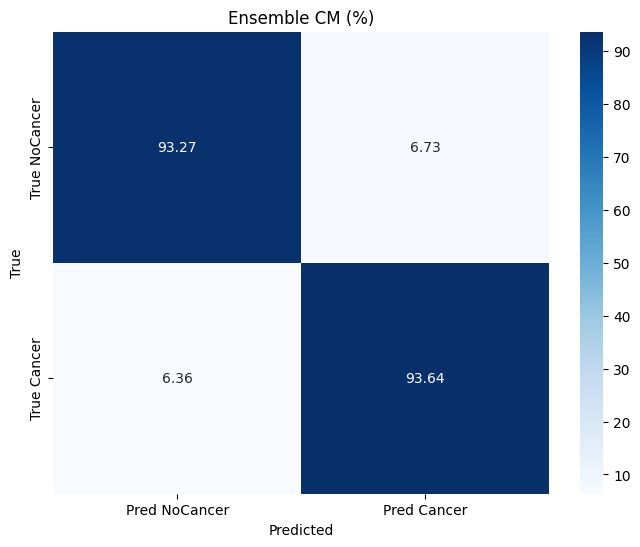


ENSEMBLE Test Acc:0.9344, Dice:0.9267, IoU:0.8634, AUC:0.9771, TPR:0.9364, TNR:0.9327, Prec:0.9172


In [ ]:
# ### REFACTORED: Step 3 - Directly evaluate on the Test Set ###
# The val_loader and find_optimal_ensemble_threshold call are REMOVED.
print("\n--- Evaluating Ensemble Performance on Hold-Out Test Set ---")
ensemble_metrics = None
try:
    ensemble_metrics = analyze_ensemble_metrics(
        models_list=ensemble_models,
        model_weights=optimal_weights,      # Use weights from the recipe
        test_loader=test_loader,
        device=device,
        optimal_threshold=optimal_threshold # Use threshold from the recipe
    )
except Exception as e:
    print(f"Error during final ensemble evaluation: {e}")
    import traceback; traceback.print_exc()

In [ ]:
# --- Visualization & Reporting (Unchanged) ---
if ensemble_metrics:
    print("\n--- Visualizing Ensemble Predictions on Test Set ---")
    visualize_ensemble_predictions(
        models_list=ensemble_models,
        model_weights=optimal_weights,
        dataloader=test_loader,
        device=device,
        threshold=optimal_threshold,
        num_samples=5
    )

    print("\n--- Final Ensemble Performance Summary ---")
    for metric, value in ensemble_metrics.items():
        print(f"  {metric.replace('_',' ').title()}: {value:.4f}")
else:
    print("\nEnsemble evaluation failed.")

print("\n--- Final Evaluation Script Finished ---")

Output hidden; open in https://colab.research.google.com to view.